### Online Retail Analytics
#### Exploratory Data Analysis (EDA)
The objective of this notebook is to explore the cleaned online retail dataset, identify sales patterns, analyze customer and product performance, and generate business insights through visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("data/cleaned/online_retail_cleaned.csv",dtype={"Invoice": str})

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,Month_Name,Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,12,December,2009
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,December,2009
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,December,2009
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,12,December,2009
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,12,December,2009


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 12 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1007913 non-null  str    
 1   StockCode    1007913 non-null  str    
 2   Description  1007913 non-null  str    
 3   Quantity     1007913 non-null  int64  
 4   InvoiceDate  1007913 non-null  str    
 5   Price        1007913 non-null  float64
 6   Customer ID  779425 non-null   float64
 7   Country      1007913 non-null  str    
 8   Revenue      1007913 non-null  float64
 9   Month        1007913 non-null  int64  
 10  Month_Name   1007913 non-null  str    
 11  Year         1007913 non-null  int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 92.3 MB


In [5]:
df.shape

(1007913, 12)

In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue', 'Month', 'Month_Name',
       'Year'],
      dtype='str')

In [7]:
# Convert InvoiceDate back to datetime
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

#### Exploratory Data Analysis
#### Business Overview

In [8]:
# Total Revenue
print("Total Revenue:",df["Revenue"].sum())

Total Revenue: 20476260.448


In [9]:
# Total Orders
print("Total Orders:",df["Invoice"].nunique())

Total Orders: 40077


In [10]:
# Total Customers
print("Total Customers:",df["Customer ID"].nunique())

Total Customers: 5878


In [11]:
# Total Countries
print("Total Countries:",df["Country"].nunique())

Total Countries: 43


#### Monthly Revenue Trend

In [12]:
monthly_revenue=(df.groupby("Month_Name")["Revenue"].sum().sort_values(ascending=False))

In [13]:
monthly_revenue

Month_Name
November     2968159.922
October      2313165.950
December     2281745.010
September    1978132.183
March        1547130.521
June         1510084.320
August       1453093.290
May          1427002.110
July         1366886.391
January      1340966.722
April        1215843.743
February     1074050.286
Name: Revenue, dtype: float64

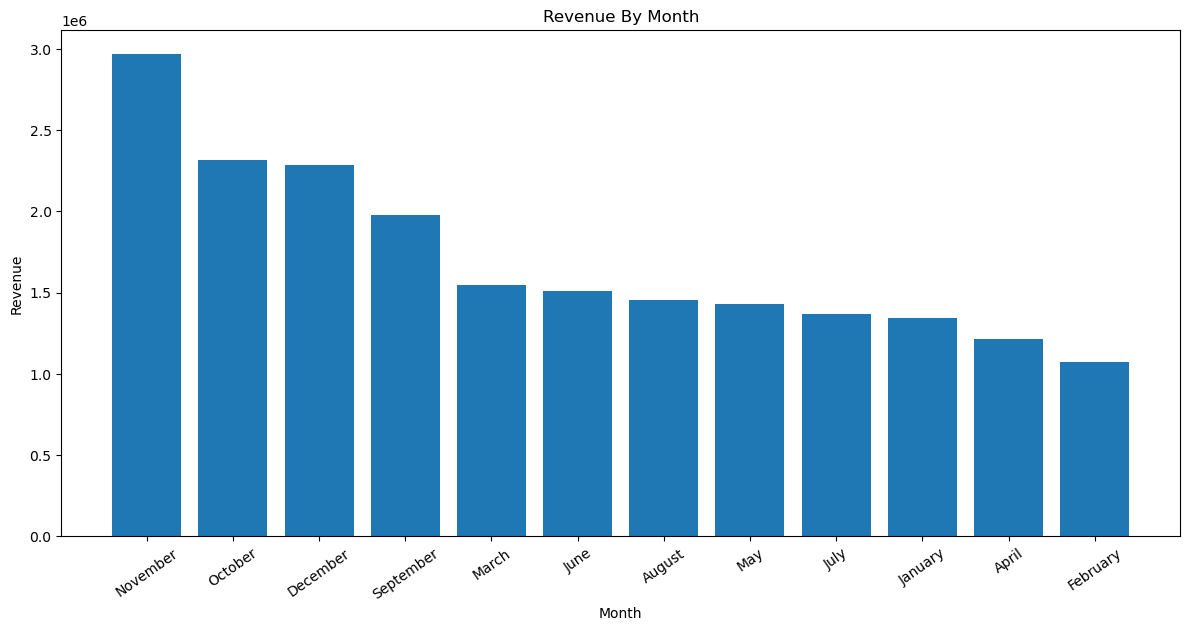

In [14]:
# Monthly Revenue Graph
plt.figure(figsize=(12,6))
plt.bar(monthly_revenue.index,monthly_revenue.values)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Revenue By Month")
plt.tight_layout()
plt.xticks(rotation=35)
plt.savefig("C:/Users/ishan/Desktop/Online Retail Analytics/visualizations/monthly_revenue_trend.png",
dpi=300, bbox_inches="tight")
plt.show()

#### Monthly Order Trend

In [16]:
monthly_orders=(df.groupby("Month_Name")["Invoice"].nunique().sort_values(ascending=False))

In [17]:
monthly_orders

Month_Name
November     5516
October      4341
December     4060
September    3676
May          3181
June         3178
March        3135
July         3004
August       2786
April        2708
February     2301
January      2191
Name: Invoice, dtype: int64

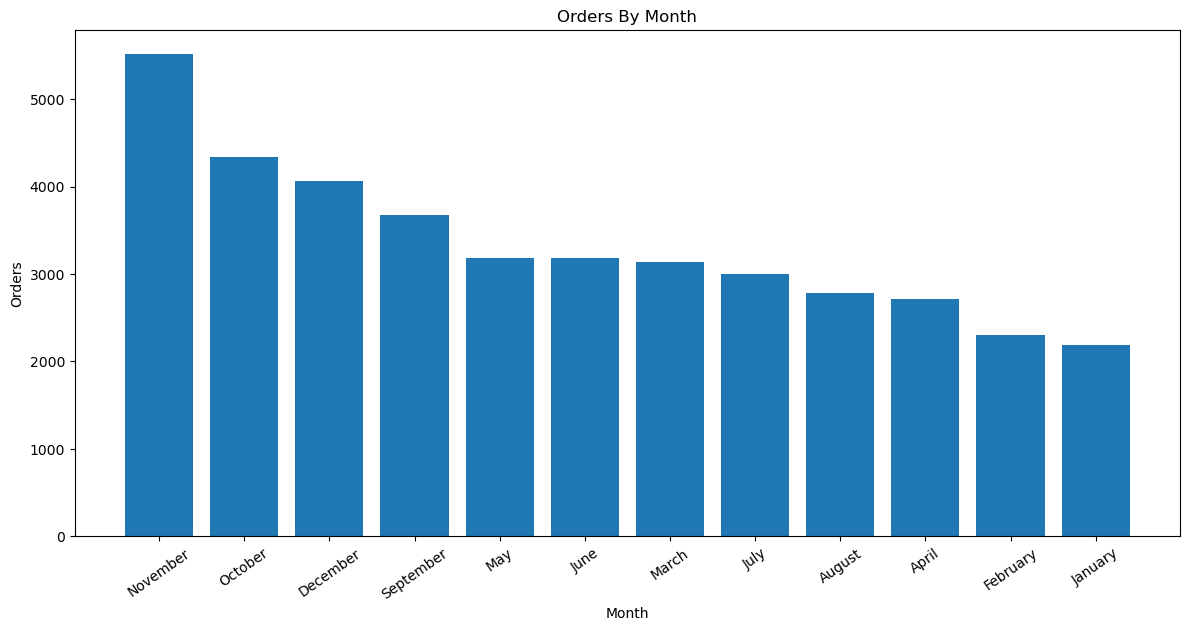

In [18]:
# Monthly Orders Graph
plt.figure(figsize=(12,6))
plt.bar(monthly_orders.index,monthly_orders.values)
plt.xlabel("Month")
plt.ylabel("Orders")
plt.title("Orders By Month")
plt.tight_layout()
plt.xticks(rotation=35)
plt.savefig("C:/Users/ishan/Desktop/Online Retail Analytics/visualizations/monthly_order_trend.png",
dpi=300, bbox_inches="tight")
plt.show()

#### Product Analysis

In [58]:
# Products that generated the most revenue

In [19]:
top_products_revenue=(df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10))

In [20]:
top_products_revenue

Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: Revenue, dtype: float64

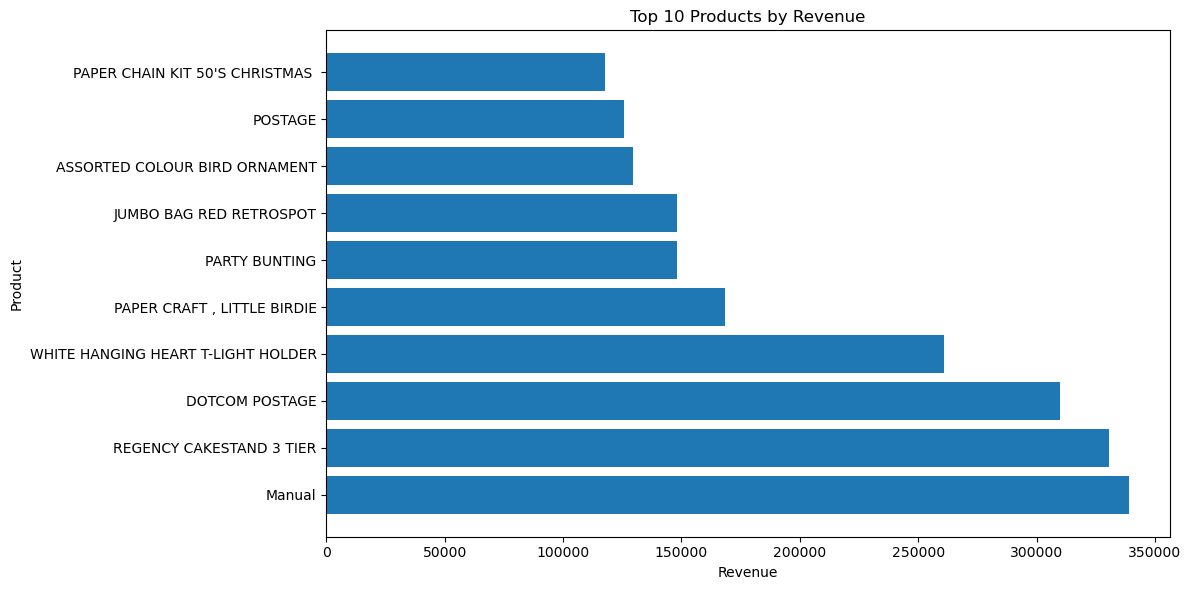

In [21]:
# Graph for these
plt.figure(figsize=(12,6))
plt.barh(top_products_revenue.index,top_products_revenue.values)
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")
plt.tight_layout()
plt.savefig("C:/Users/ishan/Desktop/Online Retail Analytics/visualizations/top_revenue_products.png",
dpi=300, bbox_inches="tight")
plt.show()

In [64]:
# Products that solds the most units

In [22]:
top_products_quantity=(df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10))

In [23]:
top_products_quantity

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77699
BROCADE RING PURSE                     70369
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48561
Name: Quantity, dtype: int64

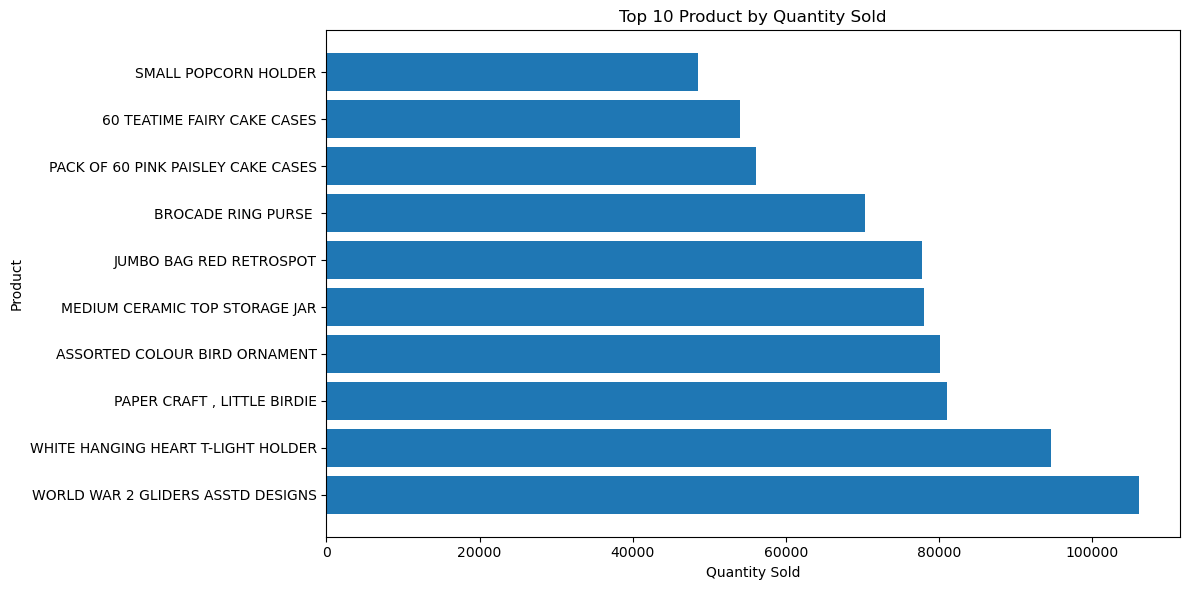

In [24]:
# Graph for these
plt.figure(figsize=(12,6))
plt.barh(top_products_quantity.index,top_products_quantity.values)
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.title("Top 10 Product by Quantity Sold")
plt.tight_layout()
plt.savefig("C:/Users/ishan/Desktop/Online Retail Analytics/visualizations/top_selling_products.png",
dpi=300, bbox_inches="tight")
plt.show()

#### Insight
The highest revenue-generating products are not always the highest quantity-selling products, indicating that product pricing significantly impacts revenue contribution.

#### Country Analysis

In [68]:
# Countries that generated the most revenue

In [25]:
top_countries_revenue=(df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10))

In [26]:
top_countries_revenue

Country
United Kingdom    1.741020e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

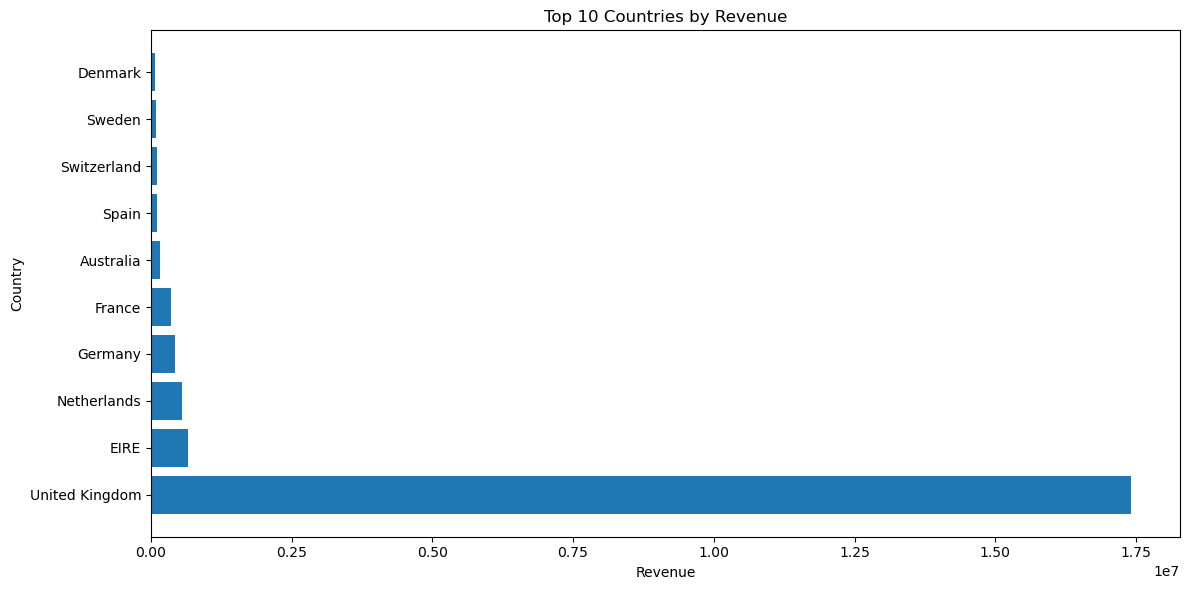

In [28]:
# Graph for Countries generating the most revenue
plt.figure(figsize=(12,6))
plt.barh(top_countries_revenue.index,top_countries_revenue.values)
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.title("Top 10 Countries by Revenue")
plt.tight_layout()
plt.savefig("C:/Users/ishan/Desktop/Online Retail Analytics/visualizations/revenue_by_country.png",
dpi=300, bbox_inches="tight")
plt.show()

In [72]:
# Countries that place the most orders

In [29]:
top_countries_orders=(df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False).head(10))

In [30]:
top_countries_orders

Country
United Kingdom    36535
Germany             789
EIRE                626
France              622
Netherlands         228
Spain               154
Belgium             149
Sweden              105
Portugal             95
Australia            95
Name: Invoice, dtype: int64

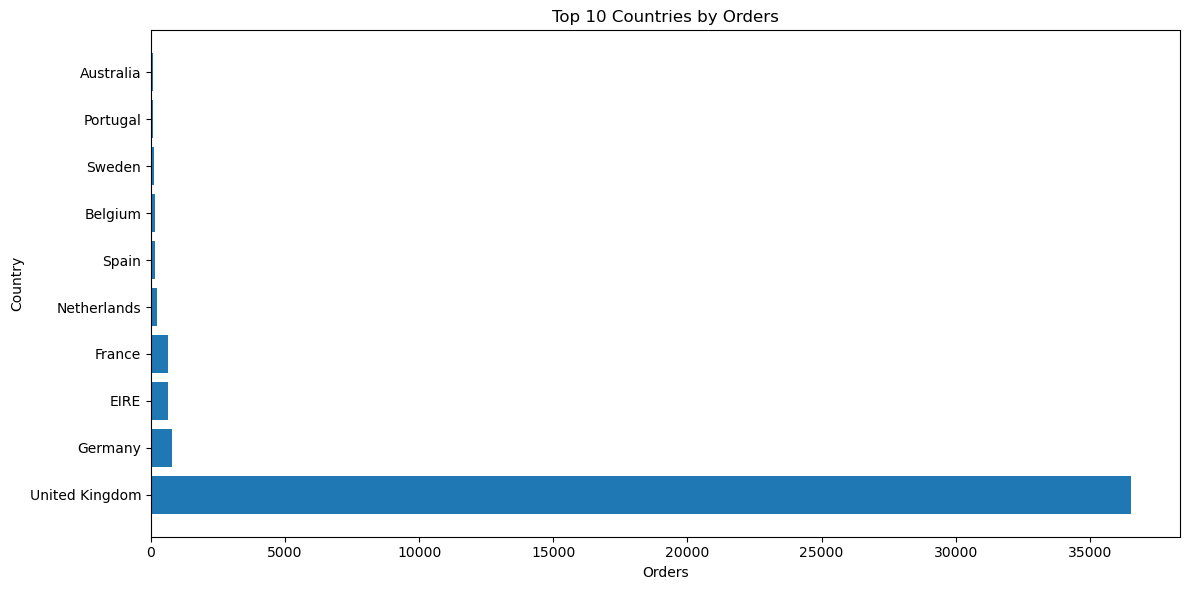

In [75]:
# Graph for Countries that orders the most
plt.figure(figsize=(12,6))
plt.barh(top_countries_orders.index,top_countries_orders.values)
plt.xlabel("Orders")
plt.ylabel("Country")
plt.title("Top 10 Countries by Orders")
plt.tight_layout()
plt.show()

#### Insight
The United Kingdom contributes the majority of total revenue and orders, making it the most important market for the business. Other European countries contribute significantly but at a much smaller scale.

#### Customer Analysis

In [84]:
# Top Customers by Revenue

In [31]:
top_customers=(df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False).head(10))

In [32]:
top_customers

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

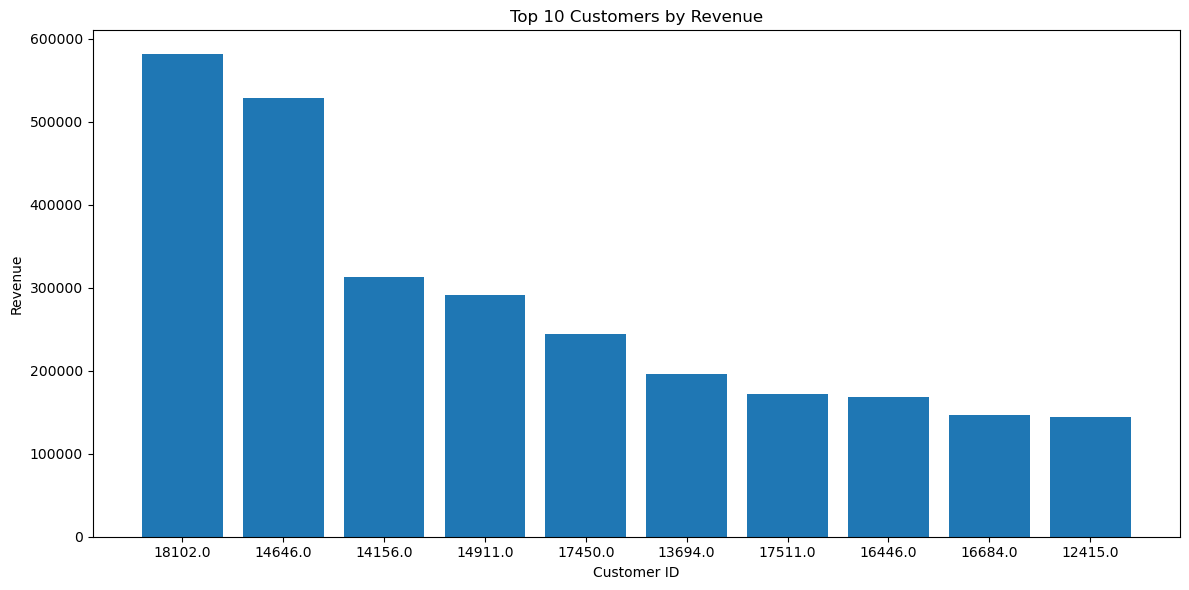

In [34]:
# Graph of Top Customer by Revenue
plt.figure(figsize=(12,6))
plt.bar(top_customers.index.astype(str),top_customers.values)
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.title("Top 10 Customers by Revenue")
plt.tight_layout()
plt.savefig("C:/Users/ishan/Desktop/Online Retail Analytics/visualizations/top_customers.png",
dpi=300, bbox_inches="tight")
plt.show()

#### Observation
A small number of customers generate a disproportionately large amount of revenue, indicating the presence of high-value customers, with Customer having CustomerID 18102.0 generating the highest revenue of (580987.04)

In [90]:
# Customers who orders most frequently

In [91]:
top_customers_orders=(df.groupby("Customer ID")["Invoice"].nunique().sort_values(ascending=False).head(10))

In [92]:
top_customers_orders

Customer ID
14911.0    398
12748.0    336
17841.0    211
15311.0    208
13089.0    203
14606.0    192
14156.0    156
17850.0    155
14646.0    151
18102.0    145
Name: Invoice, dtype: int64

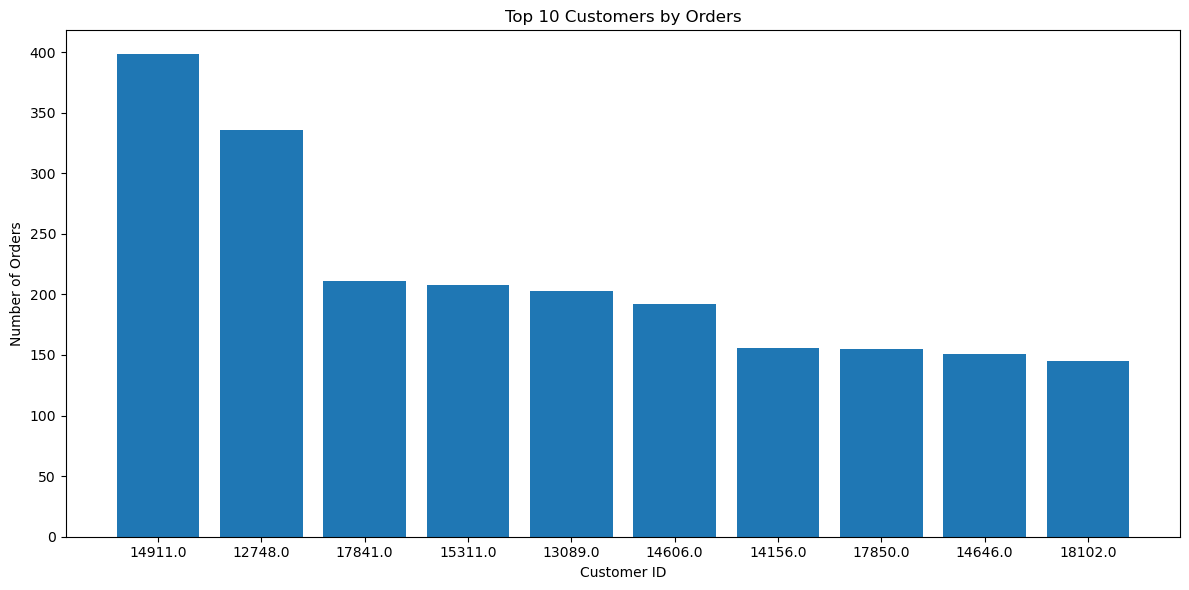

In [94]:
# Graph for customers who orders most frequently
plt.figure(figsize=(12,6))
plt.bar(top_customers_orders.index.astype(str),top_customers_orders.values)
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.title("Top 10 Customers by Orders")
plt.tight_layout()
plt.show()

#### Observation
Some customers place orders much more frequently than others, suggesting strong repeat purchasing behavior.

In [95]:
# Customer Spending Distribution

In [97]:
customer_revenue=(df.groupby("Customer ID")["Revenue"].sum())

In [98]:
customer_revenue

Customer ID
12346.0    77556.46
12347.0     4921.53
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
             ...   
18283.0     2664.90
18284.0      461.68
18285.0      427.00
18286.0     1296.43
18287.0     4182.99
Name: Revenue, Length: 5878, dtype: float64

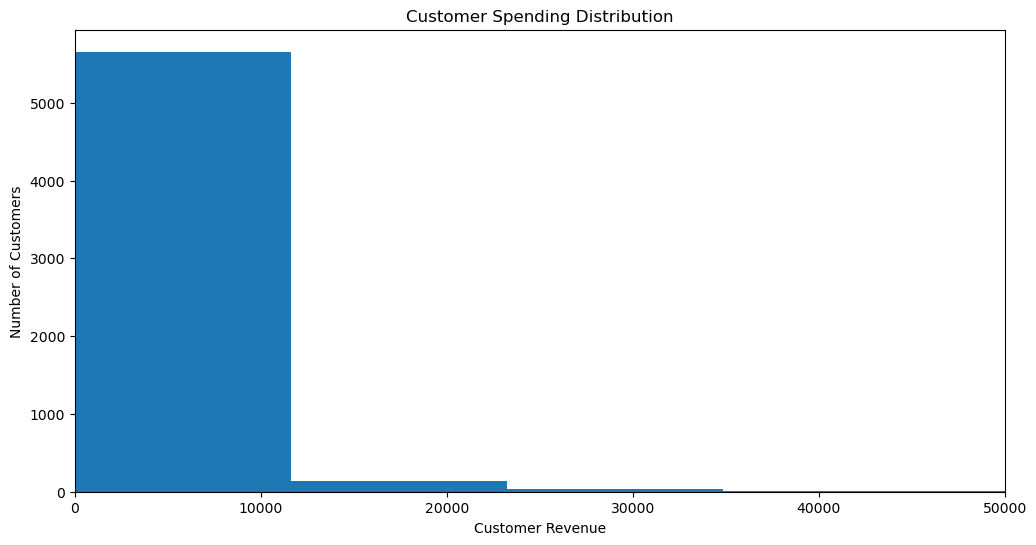

In [103]:
# Graph showing distribution of revenue by customers
plt.figure(figsize=(12,6))
plt.hist(customer_revenue,bins=50)
plt.xlim(0,50000)
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")
plt.title("Customer Spending Distribution")
plt.show()

#### Observation
Most customers contribute relatively low revenue, while a small number of customers account for a large share of total sales.

#### Correlation Analysis

In [106]:
# Relationship between Quantity, Price and Revenue

In [36]:
corr_table=df[["Quantity","Price","Revenue"]].corr()

In [37]:
corr_table

,Quantity,Price,Revenue
Quantity,1.000000,-0.003855,0.806920
Price,-0.003855,1.000000,0.247036
Revenue,0.806920,0.247036,1.000000


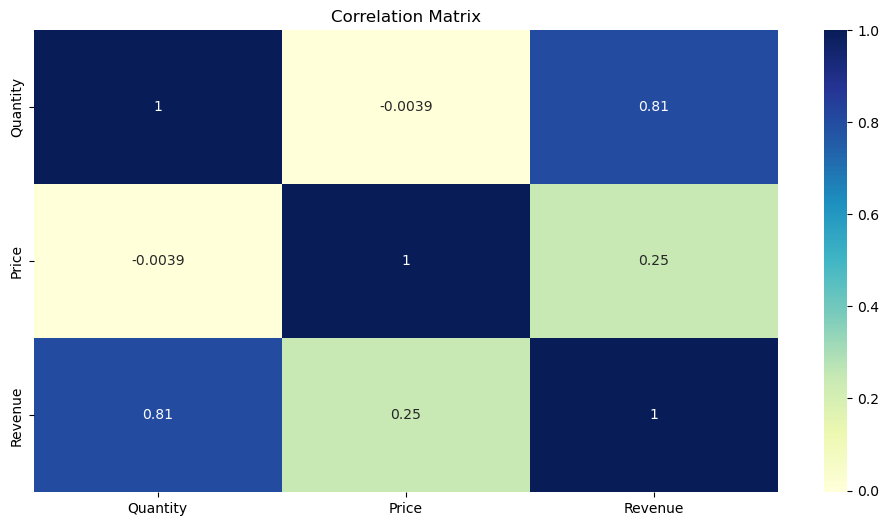

In [39]:
# Heatmap showing the relationship between Quantity, Price and Revenue
plt.figure(figsize=(12,6))
sns.heatmap(corr_table,annot=True,cmap="YlGnBu")
plt.title("Correlation Matrix")
plt.savefig("C:/Users/ishan/Desktop/Online Retail Analytics/visualizations/correlation_heatmap.png",
dpi=300, bbox_inches="tight")
plt.show()

#### Business Insight
The correlation analysis shows a **strong positive relationship (0.81)** between **Quantity** and **Revenue**, indicating that larger purchase quantities are the primary driver of revenue.

**Price** has only a **weak positive correlation (0.25)** with **Revenue**, suggesting that higher-priced products contribute to revenue but have a smaller overall impact than sales volume.

There is **almost no relationship (-0.004)** between **Price** and **Quantity**, indicating that product prices do not appear to significantly influence the quantity purchased in this dataset.

#### Key Business Insights
- November consistently recorded the highest revenue and order volume, highlighting strong seasonal demand.
- A relatively small number of products contributed disproportionately to total revenue.
- The United Kingdom was the dominant market, contributing the majority of overall revenue.
- Revenue was concentrated among a relatively small group of high-value customers.
- Customer spending exhibited a highly right-skewed distribution, with most customers generating relatively low revenue and a few contributing exceptionally high revenue.
- Sales volume showed a much stronger relationship with revenue than product pricing, indicating that quantity sold was the primary driver of revenue.